# March Madness — Feature Analysis

**Cell 1** runs 'functions.py' (Parts 2–4) and pulls every trained object into this notebook's scope.
Make sure 'RegSeasonStats.csv', 'MMHistoricResults.csv', and 'MTeams.csv'are in the same directory as this notebook, then run the cells in order.

In [17]:
# ── Load functions.py and train all models ──────────────────────────────
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Import every function from functions.py
from functions import (
    build_historic_results, build_datasets,
    run_baselines, prepare_features,
    train_logistic, train_random_forest,
    train_gradient_boosting, train_neural_network,
    MODEL_OUT
)

#part 2 — add team names to game records
games = build_historic_results()

#part 3 — build "mega" + model datasets
model_df, base_cols = build_datasets(games)

#part 4 — train all models
df = pd.read_csv(MODEL_OUT)
run_baselines(df)

X, y, _ = prepare_features(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model   = train_logistic(X_train, X_test, y_train, y_test)
rfModel = train_random_forest(X_train, X_test, y_train, y_test)
gbModel = train_gradient_boosting(X_train, X_test, y_train, y_test)
model_nn, scaler, X_test_t, nn_probs = train_neural_network(X_train, X_test, y_train, y_test)
X_test_scaled = scaler.transform(X_test)

print('\nAll models ready!')

Saved MMHistoricResultsNEW.csv
Mega dataset saved: MarchMadness_MegaDataset_2010_2025.csv (1001, 97)
Model dataset saved: MarchMadness_ModelDataset_2010_2025.csv (1001, 105)
Seed Only Accuracy:          73.13%
Lower-seed-wins baseline:    76.09%
Empirical matchup baseline:  73.91%
Logistic Regression accuracy: 76.12%
       Feature  Coefficient  AbsValue
  barthag_diff    -2.470271  2.470271
     efgd_diff    -0.394233  0.394233
      2pd_diff     0.258670  0.258670
      efg_diff     0.147391  0.147391
      3pd_diff     0.147118  0.147118
       2p_diff    -0.133935  0.133935
       3p_diff    -0.122164  0.122164
     wins_diff     0.076942  0.076942
      tor_diff     0.053935  0.053935
    adjoe_diff     0.049964  0.049964
      drb_diff     0.040133  0.040133
      ftr_diff    -0.035706  0.035706
adj_tempo_diff    -0.030851  0.030851
     rank_diff    -0.028148  0.028148
      wab_diff    -0.026298  0.026298
      3pr_diff    -0.013045  0.013045
     3prd_diff    -0.012958  0.0129

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

## Plot 1: Model Accuracy Comparison

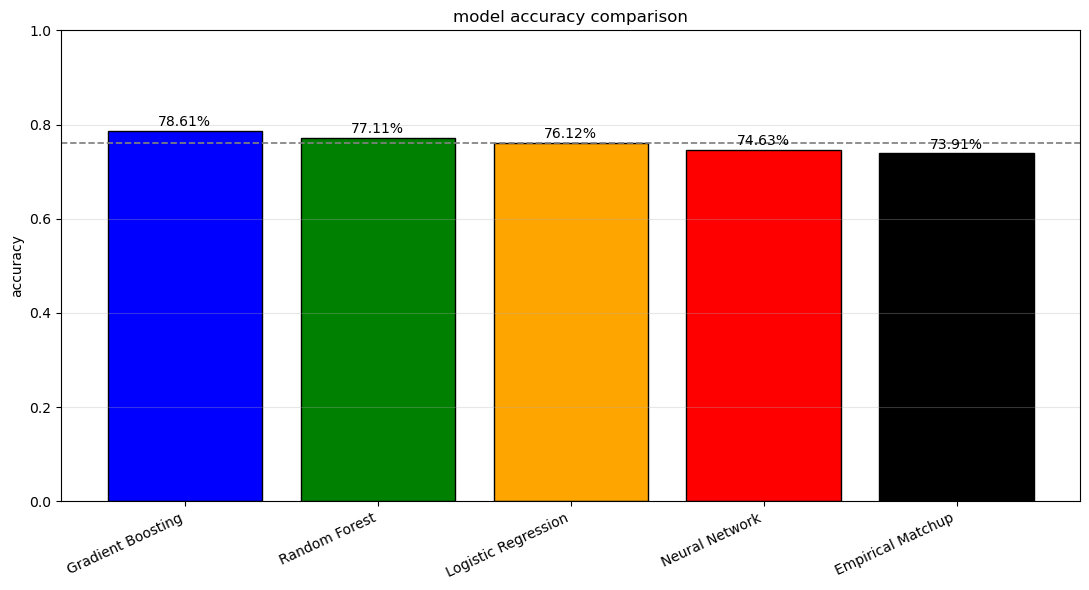

In [19]:
model_colors = {
    "Baseline (Empirical) Matchup": "darkgray",
    "Logistic Regression":           "orange",
    "Random Forest":                  "green",
    "Gradient Boosting":              "blue",
    "Neural Network":                 "red",
}
# generate predictions from each trained model on the test dataset
log_pred = model.predict(X_test)
rf_pred  = rfModel.predict(X_test)
gb_pred  = gbModel.predict(X_test)

model_nn.eval()
with torch.no_grad():
    nn_probs = model_nn(torch.tensor(X_test_scaled, dtype=torch.float32)).numpy().ravel()
nn_pred = (nn_probs > 0.5).astype(int)

model_results = [
    {"Model": "Empirical Matchup",    "Accuracy": 0.7391},
    {"Model": "Logistic Regression",  "Accuracy": accuracy_score(y_test, log_pred)},
    {"Model": "Random Forest",        "Accuracy": accuracy_score(y_test, rf_pred)},
    {"Model": "Gradient Boosting",    "Accuracy": accuracy_score(y_test, gb_pred)},
    {"Model": "Neural Network",       "Accuracy": accuracy_score(y_test, nn_pred)},
]

performance_df = pd.DataFrame(model_results)
accuracy_plot  = performance_df.sort_values("Accuracy", ascending=False)
colors = [model_colors.get(m, "black") for m in accuracy_plot["Model"]]
#create a bar chart comparing the test accuracy of all models against the benchmark

plt.figure(figsize=(11, 6))
plt.bar(accuracy_plot["Model"], accuracy_plot["Accuracy"], color=colors, edgecolor="black")
plt.axhline(y=0.7609, color="gray", linestyle="--", linewidth=1.24)
plt.title("model accuracy comparison")
plt.ylabel("accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)

for i, acc in enumerate(accuracy_plot["Accuracy"]):
    plt.text(i, acc + 0.01, f"{acc:.2%}", ha="center")

plt.tight_layout()
plt.show()

## Plot 2: Permutation Importance Across Models

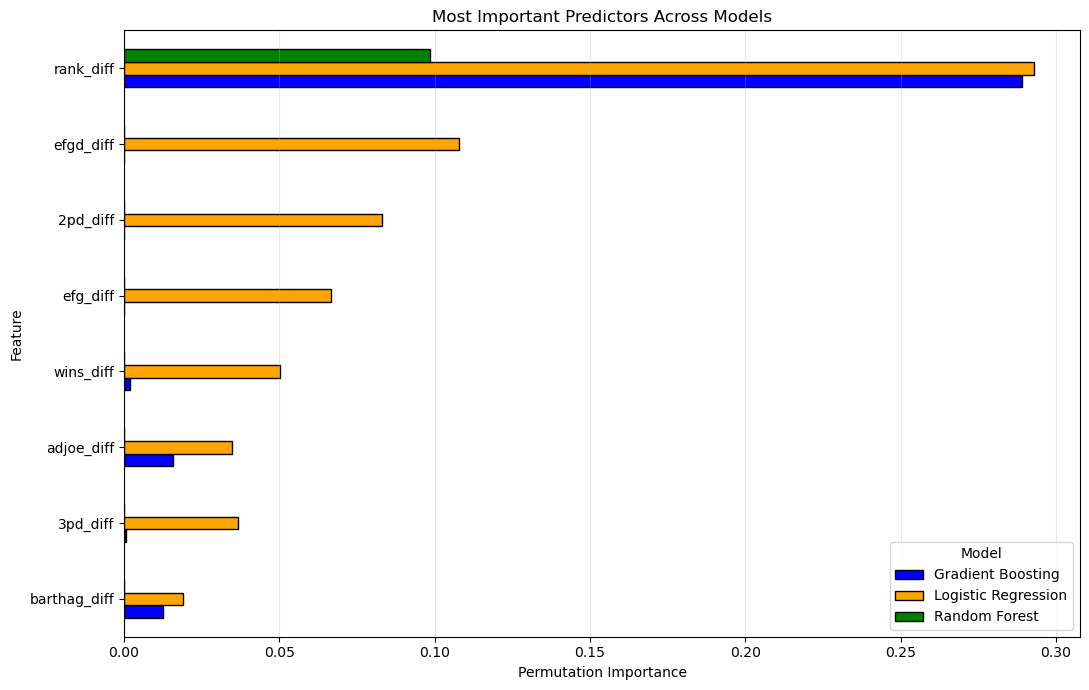

,Feature,Importance
0,rank_diff,0.226866
1,efgd_diff,0.035987
2,2pd_diff,0.027695
3,efg_diff,0.022222
4,wins_diff,0.017413
5,adjoe_diff,0.016915
6,3pd_diff,0.012438
7,barthag_diff,0.010448
8,3p_diff,0.008955
9,2p_diff,0.006799


In [20]:
models_for_importance = {
    "Logistic Regression": model,
    "Random Forest":        rfModel,
    "Gradient Boosting":    gbModel,
}
#masure feature importance by quantifying the decrease in model accuracy when each feature is randomly shuffled

importance_tables = []
for model_name, fitted_model in models_for_importance.items():
    result = permutation_importance(
        fitted_model, X_test, y_test,
        n_repeats=10, random_state=42, scoring="accuracy"
    )
    importance_tables.append(pd.DataFrame({
        "Feature":    X_test.columns,
        "Model":      model_name,
        "Importance": result.importances_mean,
    }))

all_importances = pd.concat(importance_tables, ignore_index=True)
all_importances["Importance"] = all_importances["Importance"].clip(lower=0)

top_features = (
    all_importances.groupby("Feature")["Importance"]
    .mean().sort_values(ascending=False).head(8).index
)

importance_pivot = (
    all_importances[all_importances["Feature"].isin(top_features)]
    .pivot_table(index="Feature", columns="Model", values="Importance")
    .fillna(0)
)
importance_pivot["Average"] = importance_pivot.mean(axis=1)
importance_pivot = importance_pivot.sort_values("Average", ascending=True).drop(columns="Average")

plot_colors = [model_colors.get(m, "black") for m in importance_pivot.columns]
#identify the most influential predictors across models and visualize their permutation importance scores
importance_pivot.plot(kind="barh", figsize=(11, 7), color=plot_colors, edgecolor="black")
plt.title("Most Important Predictors Across Models")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

#top 10 features table
top_feature_table = (
    all_importances.groupby("Feature")["Importance"]
    .mean().sort_values(ascending=False).head(10).reset_index()
)
display(top_feature_table)

## Plot 3: Confusion Matrices

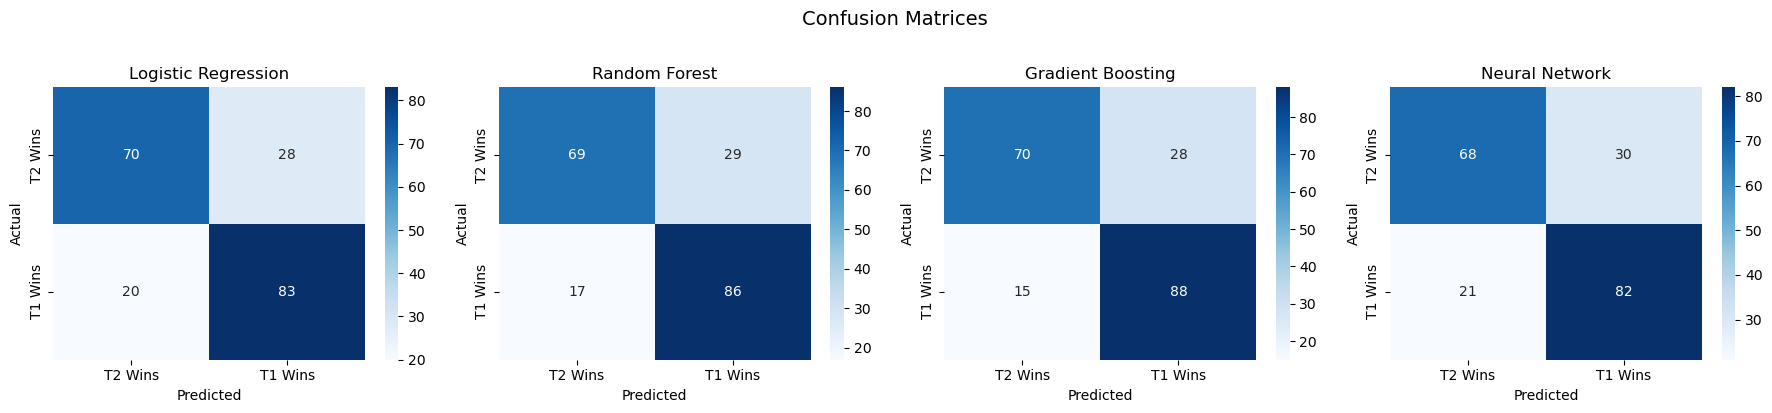

In [21]:
preds = {
    "Logistic Regression": log_pred,
    "Random Forest":        rf_pred,
    "Gradient Boosting":    gb_pred,
    "Neural Network":       nn_pred,
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["T2 Wins", "T1 Wins"],
                yticklabels=["T2 Wins", "T1 Wins"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Plot 4: ROC Curves

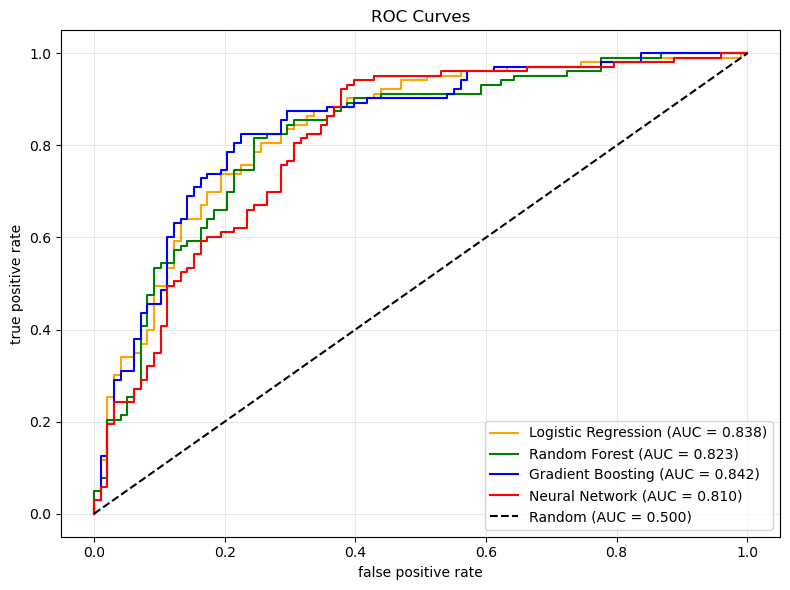

In [22]:
roc_models = {
    "Logistic Regression": model.predict_proba(X_test)[:, 1],
    "Random Forest":        rfModel.predict_proba(X_test)[:, 1],
    "Gradient Boosting":    gbModel.predict_proba(X_test)[:, 1],
    "Neural Network":       nn_probs,
}

fig, ax = plt.subplots(figsize=(8, 6))
for name, probs in roc_models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", color=model_colors[name])

ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ROC Curves")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Plot 5: Predicted Win Probability Distributions

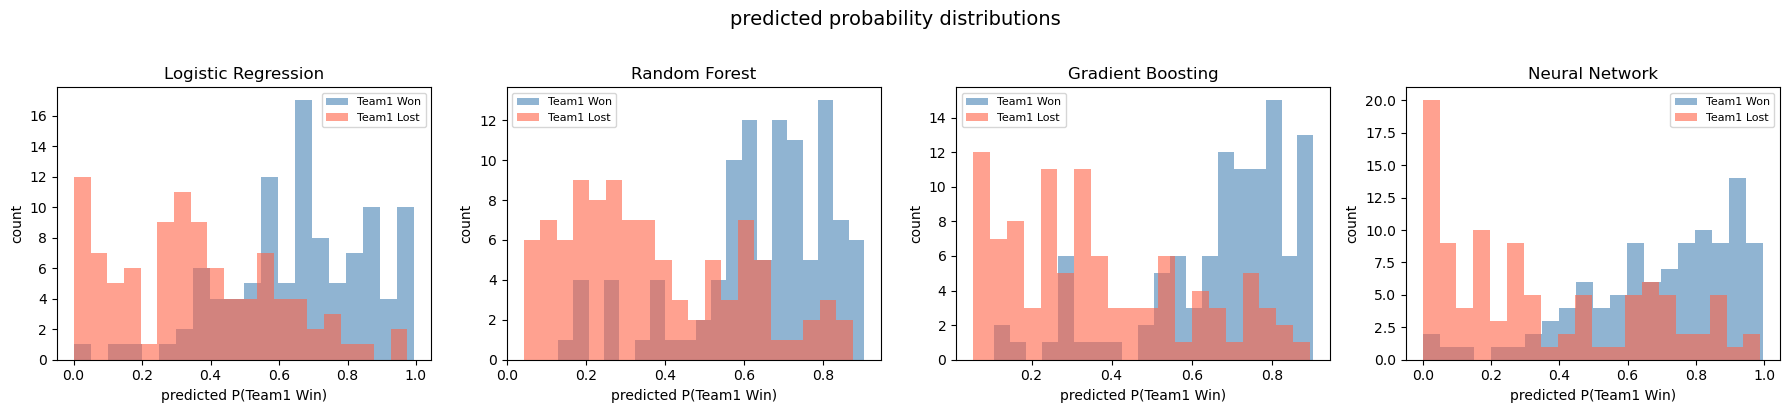

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, probs) in zip(axes, roc_models.items()):
    for outcome, label, color in [(1, "Team1 Won", "steelblue"), (0, "Team1 Lost", "tomato")]:
        mask = np.array(y_test) == outcome
        ax.hist(probs[mask], bins=20, alpha=0.6, label=label, color=color)
    ax.set_title(name)
    ax.set_xlabel("predicted P(Team1 Win)")
    ax.set_ylabel("count")
    ax.legend(fontsize=8)

plt.suptitle("predicted probability distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Plot 6: Logistic Regression Coefficients

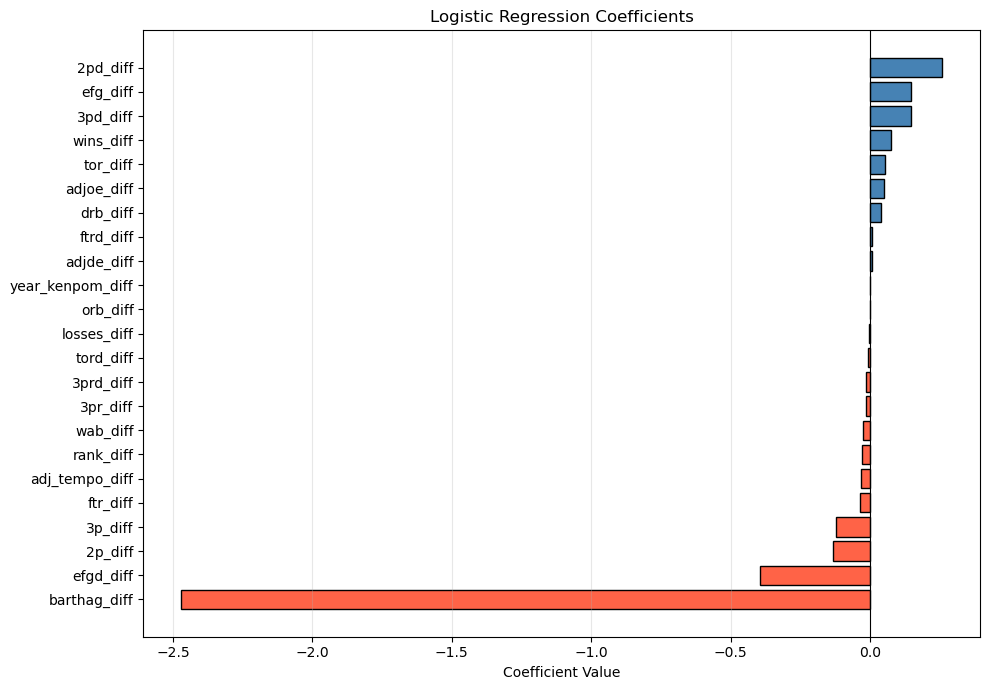

In [24]:
coef_df = pd.DataFrame({
    "Feature":     X_test.columns,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient")

colors_coef = ["tomato" if c < 0 else "steelblue" for c in coef_df["Coefficient"]]

plt.figure(figsize=(10, 7))
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors_coef, edgecolor="black")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.title("logistic regression coefficients")
plt.xlabel("coefficient value")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()